In [70]:
## Data içe aktarma
import pandas as pd 
path = "telco.csv"
df = pd.read_csv(path)


In [71]:
## Data üzerinde  keşfetme 
## df.isnull().sum()             # Colonların toplam null değerlerini görme 
#print(df.duplicated().sum())    # tekrar eden satırları görme
df.info()                        # Tablo tiplerini görme




<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [72]:
def kolon_kesfetme(kolonlar):
    for kolon in kolonlar:
        print(f"---{kolon} Kolonu---")

        secenek_sayisi = df[kolon].nunique()
        print(f"Toplam farklı seçenek sayısı {secenek_sayisi}")

        print(df[kolon].value_counts())
        print("\n" + "="*30 + "\n")

#Kolon silme
def kolon_silme(kolonlar):
    if isinstance(kolonlar , str):
        kolonlar = [kolonlar]
    df.drop(kolonlar, axis=1, inplace=True)
    print(f"Silinen Kolonlar: {kolonlar}")
    print(f"Kalan güncel kolon sayısı: {df.shape[1]}")

#Binary Dönüştürme
def binary_donusturucu(string_kolonlar):
    for kolon in string_kolonlar:
        benzersiz_degerler = df[kolon].unique()
        if len(benzersiz_degerler) == 2:
            val1, val2 = benzersiz_degerler[0], benzersiz_degerler[1]
            df[kolon] = df[kolon].map({val1: 0, val2: 1})
            print(f"'{kolon}' kolonu otomatik olarak sayısala çevrildi: {val1}=0, {val2}=1")

            
# Çoklu yappıyı int yapma one encoding
def one_encondig(kolon_adi):
    global df 
    df = pd.get_dummies(df , columns=[kolon_adi] , drop_first=True , dtype=int)
    print(f"{kolon_adi} kolonu One-Hot Encoding ile başarıyla dönüştürüldü")
    print(f"Güncel toplam kolon sayısı {df.shape[1]}")


#outlier tespit etme 
def outlier_tespit(kolonlar):
    for kolon in kolonlar:
        Q1 = df[kolon].quantile(0.25)
        Q3 = df[kolon].quantile(0.75)
        IQR = Q3 - Q1
    
        alt_sinir = Q1 - 1.5 * IQR
        ust_sinir = Q3 + 1.5 * IQR
    
        # Sınırların dışında kalanları buluyoruz
        aykirilar = df[(df[kolon] < alt_sinir) | (df[kolon] > ust_sinir)]
        print(f"{kolon} kolonunda {len(aykirlar) if 'aykirlar' in locals() else len(aykirilar)} adet aykırı değer var.")

In [73]:
    # customerId kolonu yapı olarak int çevrilemiyceği için sildim
kolon_kesfetme(["customerID"])
kolon_silme(["customerID"])
        #Partner
kolon_kesfetme(["Partner"])
binary_donusturucu(["Partner"])

        #gender
kolon_kesfetme(["gender"])
binary_donusturucu(["gender"])

        #Dependents
kolon_kesfetme(["Dependents"])
binary_donusturucu(["Dependents"])
 
       #PhoneService
kolon_kesfetme(['PhoneService'])
binary_donusturucu(['PhoneService'])

        # MultipleLines
kolon_kesfetme(['MultipleLines'])
one_encondig('MultipleLines')
 
       #InternetService
kolon_kesfetme(['InternetService'])
one_encondig('InternetService')

        #OnlineSecurity
kolon_kesfetme(['OnlineSecurity'])
one_encondig('OnlineSecurity')
         

           #OnlineBackup
kolon_kesfetme(['OnlineBackup'])
one_encondig("OnlineBackup")


        #DeviceProtection
kolon_kesfetme(['DeviceProtection'])
one_encondig("DeviceProtection")
    

    #TechSupport
kolon_kesfetme(["TechSupport"])
one_encondig("TechSupport")

        #StreamingTV
kolon_kesfetme(["StreamingTV"])
one_encondig("StreamingTV")

        #StreamingMovies
kolon_kesfetme(['StreamingMovies'])
one_encondig("StreamingMovies")

    #Contract
kolon_kesfetme(['Contract'])
one_encondig("Contract")

        #PaperlessBilling
kolon_kesfetme(["PaperlessBilling"])
binary_donusturucu(["PaperlessBilling"])
   

         #PaymentMethod
kolon_kesfetme(['PaymentMethod'])
one_encondig("PaymentMethod")

    #TotalCharges
kolon_kesfetme(['TotalCharges'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  #str di ancak zaten flotla dolu olduğu için kolonu numeric yaptık


        #Churn        
kolon_kesfetme(['Churn'])
binary_donusturucu(['Churn'])       


#print(df.isnull().sum())   
#df['TotalCharges'].isnull()                        #11 tane null çıktı 
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # null az olması sebei ile sıfır ile değiştirdik

---customerID Kolonu---
Toplam farklı seçenek sayısı 7043
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64


Silinen Kolonlar: ['customerID']
Kalan güncel kolon sayısı: 20
---Partner Kolonu---
Toplam farklı seçenek sayısı 2
Partner
No     3641
Yes    3402
Name: count, dtype: int64


'Partner' kolonu otomatik olarak sayısala çevrildi: Yes=0, No=1
---gender Kolonu---
Toplam farklı seçenek sayısı 2
gender
Male      3555
Female    3488
Name: count, dtype: int64


'gender' kolonu otomatik olarak sayısala çevrildi: Female=0, Male=1
---Dependents Kolonu---
Toplam farklı seçenek sayısı 2
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


'Dependents' kolonu otomatik olarak sayısala çevrildi: No=0, Yes=1
---PhoneService Kolonu---
Toplam farklı seçenek sayısı 2
PhoneService
Yes    6361
No      682
Name: count

In [74]:
#Outlier tespit etme 
#sayisal_kolonlar = df.select_dtypes(include=['int64', 'float64']).columns
#outlier_tespit(sayisal_kolonlar)

display(df.select_dtypes(include=['int64', 'float64']).describe()) # genel bilgilere bakıyoruz 

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.516967,0.299588,32.371149,0.903166,0.407781,64.761692,2279.734304,0.265370,...,0.290217,0.216669,0.384353,0.216669,0.387903,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,0.441561,...,0.453895,0.412004,0.486477,0.412004,0.487307,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,29.000000,1.000000,0.000000,70.350000,1394.550000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Müşteri Kaybını Etkileyen En Önemli Faktörler:
                                 Degisken  Onem_Derecesi
8                            TotalCharges       0.199647
4                                  tenure       0.172861
7                          MonthlyCharges       0.169204
28         PaymentMethod_Electronic check       0.039489
11            InternetService_Fiber optic       0.038618
0                                  gender       0.028281
26                      Contract_Two year       0.025453
6                        PaperlessBilling       0.025375
14                     OnlineSecurity_Yes       0.025178
2                                 Partner       0.023267
20                        TechSupport_Yes       0.023094
25                      Contract_One year       0.023007
16                       OnlineBackup_Yes       0.021275
1                           SeniorCitizen       0.021064
10                      MultipleLines_Yes       0.019573
3                              Dependents

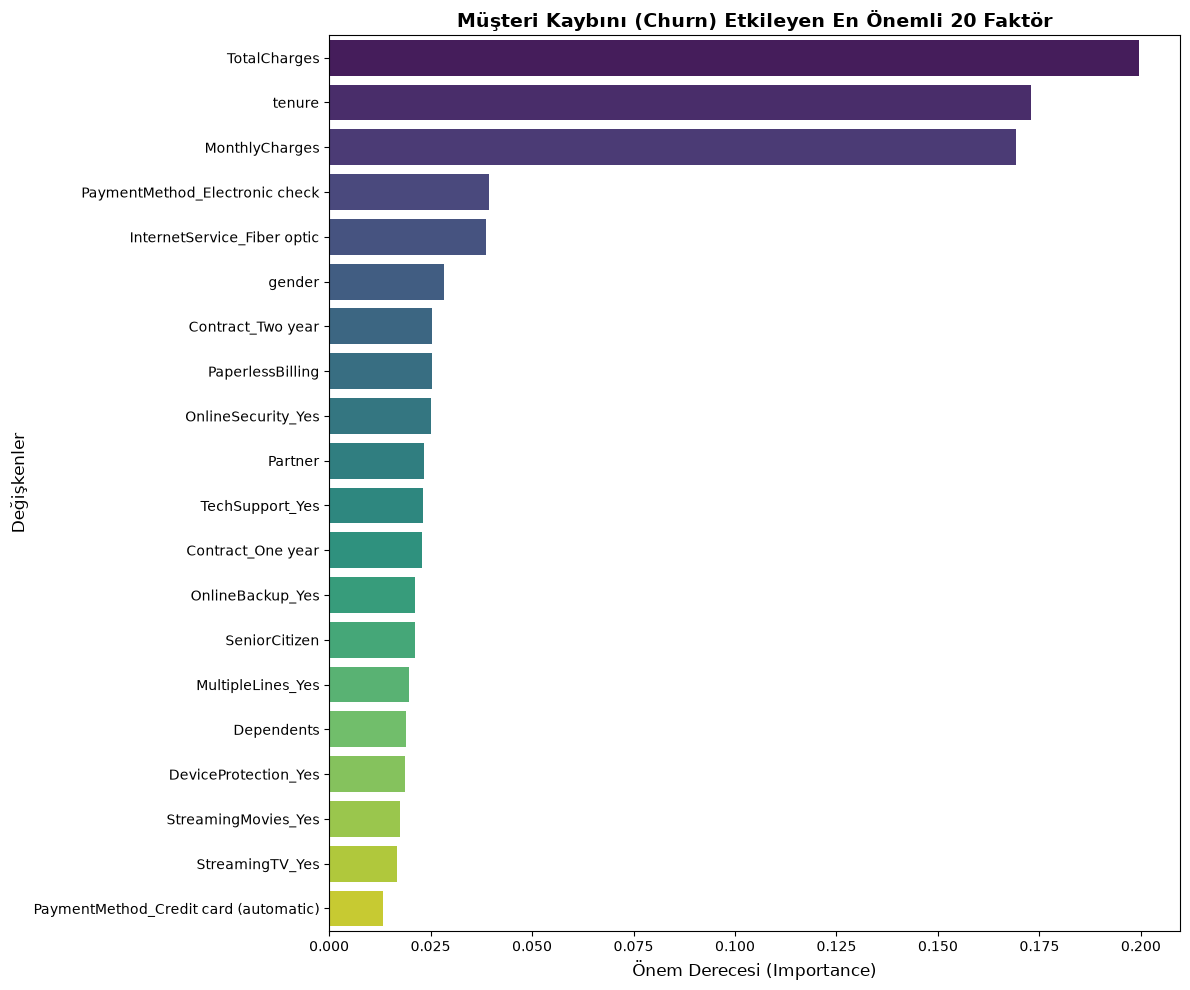

In [75]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Hedef sütununuzun adını buraya yazın
hedef_sutun = "Churn"

# 2. X (özellikler) ve y (hedef) olarak veriyi ayırın
X = df.drop(columns=[hedef_sutun])
y = df[hedef_sutun]

# Sadece sayısal sütunlarla çalışalım
X_num = X.select_dtypes(include=["number"])

# 3. Random Forest modeli kurup fit edelim
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_num, y)

# 4. Hangi sütun ne kadar önemli? Tablo haline getir ve en önemliden en aza sırala
feature_importance = pd.DataFrame(
    {"Degisken": X_num.columns, "Onem_Derecesi": model.feature_importances_}
).sort_values(by="Onem_Derecesi", ascending=False)

# Konsolda da düzgün görmek isterseniz:
print("Müşteri Kaybını Etkileyen En Önemli Faktörler:")
print(feature_importance.head(25))

# 5. Seaborn ile daha gelişmiş ve okunabilir yatay çubuk grafik (Barplot) çizdirme
plt.figure(figsize=(12, 10))

# En önemli ilk 20 değişkeni grafiğe döküyoruz (Tümü sığmayabilir, ilk 20 idealdir)
top_features = feature_importance.head(20)

sns.barplot(
    x="Onem_Derecesi",
    y="Degisken",
    data=top_features,
    palette="viridis",
    hue="Degisken",
    legend=False,
)

plt.title(
    "Müşteri Kaybını (Churn) Etkileyen En Önemli 20 Faktör",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Önem Derecesi (Importance)", fontsize=12)
plt.ylabel("Değişkenler", fontsize=12)
plt.tight_layout()
plt.show()

In [76]:
#Model Seçme Değerlendirme 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

y= df['Churn']
X = df.drop('Churn' , axis=1)


X_tr , X_te , y_tr , y_te = train_test_split(
    X,y , test_size=0.2 , random_state=42 , stratify=y
)




models = {
    'LogisticRegression': (
        Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=1000))]),
        {'m__C': [0.1, 1, 10]},
    ),
    'KNN': (
        Pipeline([('sc', StandardScaler()), ('m', KNeighborsClassifier())]),
        {'m__n_neighbors': [3, 5, 7, 11]},
    ),
    'DecisionTree': (
        Pipeline([('m', DecisionTreeClassifier(random_state=42))]),
        {'m__max_depth': [3, 5, 10, None]},
    ),
    'RandomForest': (
        Pipeline([('m', RandomForestClassifier(random_state=42, n_jobs=-1))]),
        {'m__n_estimators': [50, 100, 200], 'm__max_depth': [5, 10, None]},
    ),
    'SVM': (
        Pipeline([('sc', StandardScaler()), ('m', SVC())]),
        {'sc__with_mean': [True, False], 'm__C': [0.1, 1, 10], 'm__kernel': ['rbf', 'linear']},
    ),
}

# 1. DEĞİŞİKLİK: Döngünün hemen üstüne modelleri saklamak için boş bir sözlük ekleyin
egitilen_modeller = {}

results = []
for name, (p, params) in models.items():
    g = GridSearchCV(p, params, cv=5, scoring='f1', n_jobs=-1)
    g.fit(X_tr, y_tr)
    results.append({
        'Model':      name,
        'Best CV F1': g.best_score_,
        'Test F1':    g.score(X_te, y_te),
        'Best Params': g.best_params_,
    })
    # 2. DEĞİŞİKLİK: Her modelin eğitilmiş halini ismini anahtar yaparak sözlüğe kaydedin
    egitilen_modeller[name] = g.best_estimator_

# Sizin orijinal tablonuz (Sıralamayı isterseniz 'Test F1'e göre de değiştirebilirsiniz)
df_sonuc = pd.DataFrame(results).sort_values('Best CV F1', ascending=False)
print("\n🏆 Model Karşılaştırma — ML-04 Modül Final")
print("=" * 70)
print(df_sonuc[['Model', 'Best CV F1', 'Test F1']].to_string(index=False))
print("\nEn iyi modelin parametreleri:")
print(f"  {df_sonuc.iloc[0]['Model']}: {df_sonuc.iloc[0]['Best Params']}")


# 3. DEĞİŞİKLİK: 'g.best_estimator_' yerine tablonun 0. indeksindeki (en üstteki) modeli çağırın
en_iyi_model_ismi = df_sonuc.iloc[0]['Model']
en_iyi_model = egitilen_modeller[en_iyi_model_ismi]

# Kodun geri kalan tahmin ve metrik hesaplama kısımları orijinal haliyle aynen devam eder:
y_pred = en_iyi_model.predict(X_te)



print("="*70)
print("---Genel Değerlendirme --- ")
# Her bir metriği ayrı ayrı hesaplıyoruz
acc = accuracy_score(y_te, y_pred)
prec = precision_score(y_te, y_pred)
rec = recall_score(y_te, y_pred)
f1 = f1_score(y_te, y_pred)

print(f"Accuracy (Doğruluk): {acc:.4f}")
print(f"Precision (Hassasiyet): {prec:.4f}")
print(f"Recall (Duyarlılık / Kaçak Yakalama): {rec:.4f}")
print(f"F1-Score (Dengeli Skor): {f1:.4f}")

# Veya tek satırda hepsini tablo şeklinde veren efsane komut:
print("\n--- DETAYLI SINIFLANDIRMA RAPORU ---")
print(classification_report(y_te, y_pred))



🏆 Model Karşılaştırma — ML-04 Modül Final
             Model  Best CV F1  Test F1
LogisticRegression    0.598965 0.598266
               SVM    0.586515 0.570188
               KNN    0.572013 0.563611
      RandomForest    0.565794 0.577844
      DecisionTree    0.533755 0.533153

En iyi modelin parametreleri:
  LogisticRegression: {'m__C': 10}
---Genel Değerlendirme --- 
Accuracy (Doğruluk): 0.8027
Precision (Hassasiyet): 0.6509
Recall (Duyarlılık / Kaçak Yakalama): 0.5535
F1-Score (Dengeli Skor): 0.5983

--- DETAYLI SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [ ]:
import pandas as pd

# Test verisini ve tahminleri birleştiriyoruz
analiz_df = X_te.copy()
analiz_df['Gercek_Churn'] = y_te.values
analiz_df['Modelin_Tahmini'] = y_pred

# Modelin kaçırdığı müşteriler (False Negative - En tehlikelisi)
kacanlar = analiz_df[(analiz_df['Gercek_Churn'] == 1) & (analiz_df['Modelin_Tahmini'] == 0)]

print(f"Modelin fark edemediği kaçak müşteri sayısı: {len(kacanlar)}")
# Bu 'kacanlar' tablosundaki müşterilerin fatura tutarlarına veya sözleşme tiplerine bakarak 
# "Demek ki model şu tip müşterilerde kaçırıyor" diye yorum yapabilirsin!
# Kaçırılan müşterilerin ortalama özelliklerine bir bak (Örn: Sözleşme süreleri, aylık ödemeleri vb.)
print("\n--- Kaçırılan Müşterilerin Ortalamaları ---")
print(kacanlar.select_dtypes(include=["number"]).mean())

Modelin fark edemediği kaçak müşteri sayısı: 167


In [78]:
import pandas as pd

# 1. GridSearchCV'den çıkan en iyi modeli ve içindeki pipeline adımlarını alıyoruz
best_model = g.best_estimator_

# Not: Pipeline içinde StandardScaler olduğu için modeli ve scaler'ı ayırıp 
# orijinal sütun isimleriyle katsayıları eşleştirmemiz gerekir.
# Logistic Regression modelini ve kolon isimlerini alalım:
log_reg_model = best_model.named_steps['m']
feature_names = X.columns # X değişkenini oluşturduğun andaki kolon isimleri

# 2. Katsayıları (weights) bir DataFrame yapıyoruz
importance_df = pd.DataFrame({
    'Ozellik': feature_names,
    'Katsayi': log_reg_model.coef_[0]
})

# Katsayı büyüklüğüne göre sıralıyoruz (Mutlak değerle)
importance_df['Mutlak_Deger'] = importance_df['Katsayi'].abs()
importance_df = importance_df.sort_values(by='Mutlak_Deger', ascending=False)

print("--- MÜŞTERİNİN CHURN OLMASINI EN ÇOK ETKİLEYEN FAKTÖRLER ---")
print(importance_df[['Ozellik', 'Katsayi']].to_string(index=False))

--- MÜŞTERİNİN CHURN OLMASINI EN ÇOK ETKİLEYEN FAKTÖRLER ---
                              Ozellik   Katsayi
          InternetService_Fiber optic  0.655385
                         TotalCharges -0.537098
                               tenure -0.267661
       PaymentMethod_Electronic check  0.146519
                  StreamingMovies_Yes  0.129497
                    MultipleLines_Yes  0.114919
                    Contract_One year -0.114214
                      StreamingTV_Yes  0.108773
                      TechSupport_Yes -0.103948
                   OnlineSecurity_Yes -0.103290
                     PaperlessBilling -0.094287
                       MonthlyCharges -0.065554
                           Dependents -0.063906
           PaymentMethod_Mailed check  0.053007
                        SeniorCitizen  0.052743
                    Contract_Two year -0.050115
                     OnlineBackup_Yes -0.036622
                         PhoneService -0.031614
       MultipleLines_No pho

In [79]:
import pandas as pd

# 1. Test verisini ve tahminleri birleştiriyoruz
hata_df = X_te.copy()
hata_df['Gercek_Durum'] = y_te.values
hata_df['Modelin_Tahmini'] = y_pred

# 2. SADECE modelin yanıldığı (hata yaptığı) satırları filtreliyoruz
yanildigimiz_yerler = hata_df[hata_df['Gercek_Durum'] != hata_df['Modelin_Tahmini']]

print(f"Modelin toplam hata yaptığı müşteri sayısı: {len(yanildigimiz_yerler)}")

# Modelin kaçırdığı veya yanlış alarm verdiği ilk 5 müşteriyi inceleyelim:
print(yanildigimiz_yerler[['Gercek_Durum', 'Modelin_Tahmini']].head())

Modelin toplam hata yaptığı müşteri sayısı: 278
      Gercek_Durum  Modelin_Tahmini
2280             0                1
5748             0                1
1639             1                0
2136             0                1
950              1                0
